
# TSP/Segment Routing for Plant Watering in Surabaya (OSRM)

**Goal:** start from one depot, visit every plant **segment** (each plant has a start point and an end point), choose the best traversal direction for each segment, and optionally return to the depot.

This notebook now uses **OSRM** instead of downloading the whole road graph from OSM. The workflow is:

1. Define 1 depot and plant segments (`start_lat`, `start_lon`, `end_lat`, `end_lon`)
2. Build an OSRM **table** between depot + all segment endpoints
3. Optimize the segment visit order
4. For a fixed order, choose the best direction of each segment with dynamic programming
5. Reconstruct the full driving route from OSRM **route** geometry
6. Visualize the result in **folium**


In [1]:
%pip install requests folium numpy matplotlib

In [2]:

import requests
import numpy as np
import folium
import random
import math
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from itertools import permutations

random.seed(42)
np.random.seed(42)

# Public demo server; for production use.
OSRM_BASE = "https://router.project-osrm.org"
PROFILE = "driving"

# If True, route becomes: DEPOT -> all segments -> DEPOT
# If False, route becomes: DEPOT -> all segments
RETURN_TO_DEPOT = True

from google.colab import files

uploaded = files.upload()


Saving parks.csv to parks (1).csv


In [3]:
# ─────────────────────────────────────────────────────────────────────────
# MULTI-VEHICLE CONFIGURATION
# Set NUM_VEHICLES to any positive integer.
# Each vehicle starts and ends at the same DEPOT.
# Segments are partitioned among vehicles; the GA optimises each vehicle's
# route independently. Uneven splits are handled automatically.
# ─────────────────────────────────────────────────────────────────────────
NUM_VEHICLES = 5          # <-- change this to any number you need
RETURN_TO_DEPOT = True    # True: each vehicle returns to depot after finishing

# Segment assignment strategy:
#   'round_robin' - assigns segments one-by-one rotating across vehicles
#                   (spreads segments spatially more evenly on average)
#   'block'       - assigns contiguous chunks to each vehicle
#                   (faster if CSV rows are already geographically ordered)
ASSIGNMENT_STRATEGY = 'round_robin'

print(f'Multi-vehicle mode: {NUM_VEHICLES} vehicles, strategy={ASSIGNMENT_STRATEGY}')


Multi-vehicle mode: 5 vehicles, strategy=round_robin


## 1. Define depot and load plant segments from CSV

Each plant is a **segment**, not a single point, so the CSV should contain:

- `start_lat`, `start_lon`
- `end_lat`, `end_lon`

Optional columns:
- `park_id`
- `name`

If `name` is missing, the notebook will automatically use `park_id` or generate `Plant N`.


In [4]:
# Depot / start point
DEPOT = (-7.278358153631059, 112.76325243881848)

# CSV file path
CSV_PATH = "parks.csv"

# Required columns in the CSV
REQUIRED_COLUMNS = ["start_lat", "start_lon", "end_lat", "end_lon"]

df_segments = pd.read_csv(CSV_PATH)

missing_cols = [col for col in REQUIRED_COLUMNS if col not in df_segments.columns]
if missing_cols:
    raise ValueError(f"CSV is missing required columns: {missing_cols}")

def build_segment_name(row, idx):
    if "name" in row.index and pd.notna(row["name"]):
        return str(row["name"])
    if "park_id" in row.index and pd.notna(row["park_id"]):
        return f"Park {row['park_id']}"
    return f"Plant {idx + 1}"

PLANTS = []
for idx, row in df_segments.iterrows():
    PLANTS.append({
        "name": build_segment_name(row, idx),
        "start_lat": float(row["start_lat"]),
        "start_lon": float(row["start_lon"]),
        "end_lat": float(row["end_lat"]),
        "end_lon": float(row["end_lon"]),
    })

# print(f"Loaded {len(PLANTS)} segments from {CSV_PATH.name}")
display(df_segments.head())


,park_id,start_lat,start_lon,end_lat,end_lon
0,Jalan Kenjeran,-7.252887,112.795292,-7.249851,112.784502
1,Jalan Raya Mulyosari,-7.258301,112.795617,-7.273659,112.797714
2,Jalan Raya Kertajaya Indah,-7.279408,112.789619,-7.280560,112.781162
3,Jalan Raya Kertajaya Indah,-7.280611,112.780693,-7.279390,112.762482
4,Jalan Kertajaya,-7.279360,112.762112,-7.278325,112.756143



## 2. Prepare unique endpoints

We create one master list of coordinates:

- index 0 = depot
- every plant contributes:
  - `a_idx` = segment start endpoint
  - `b_idx` = segment end endpoint

OSRM's **table** service will give us pairwise road-network distances between all of these points.


In [5]:
POINTS = [DEPOT]
POINT_LABELS = ["Depot"]
SEGMENTS = []

for i, p in enumerate(PLANTS, start=1):
    a = (p["start_lat"], p["start_lon"])
    b = (p["end_lat"], p["end_lon"])

    a_idx = len(POINTS)
    POINTS.append(a)
    POINT_LABELS.append(f'{p["name"]} A')

    b_idx = len(POINTS)
    POINTS.append(b)
    POINT_LABELS.append(f'{p["name"]} B')

    SEGMENTS.append({
        "seg_id": i - 1,
        "name": p["name"],
        "a_idx": a_idx,
        "b_idx": b_idx,
    })

print("Total table points:", len(POINTS))
print("First 5 segments:")
for s in SEGMENTS[:5]:
    print(s)


Total table points: 69
First 5 segments:
{'seg_id': 0, 'name': 'Park Jalan Kenjeran', 'a_idx': 1, 'b_idx': 2}
{'seg_id': 1, 'name': 'Park Jalan Raya Mulyosari', 'a_idx': 3, 'b_idx': 4}
{'seg_id': 2, 'name': 'Park Jalan Raya Kertajaya Indah', 'a_idx': 5, 'b_idx': 6}
{'seg_id': 3, 'name': 'Park Jalan Raya Kertajaya Indah', 'a_idx': 7, 'b_idx': 8}
{'seg_id': 4, 'name': 'Park Jalan Kertajaya', 'a_idx': 9, 'b_idx': 10}


## Snap Coordinate

In [6]:
import time
import requests
import numpy as np

snap_cache = {}

def point_key(pt):
    return (round(pt[0], 6), round(pt[1], 6))

def osrm_nearest(pt, number=1, timeout=60):
    """
    Snap satu titik ke jaringan jalan OSRM memakai /nearest.
    pt = (lat, lon)
    return list kandidat snap
    """
    key = (point_key(pt), number)
    if key in snap_cache:
        return snap_cache[key]

    coord = f"{pt[1]:.6f},{pt[0]:.6f}"
    url = f"{OSRM_BASE}/nearest/v1/{PROFILE}/{coord}?number={number}"

    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    data = r.json()

    if data.get("code") != "Ok":
        raise RuntimeError(data)

    out = []
    for wp in data["waypoints"]:
        lon, lat = wp["location"]
        out.append({
            "input_latlon": pt,
            "snapped_latlon": (lat, lon),
            "distance_to_road_m": float(wp.get("distance", 0.0)),
            "name": wp.get("name", ""),
            "nodes": wp.get("nodes", []),
            "raw": wp,
        })

    snap_cache[key] = out
    return out

def snap_points(points, number=1, verbose=True, sleep_sec=0.05):
    """
    Snap semua titik.
    number=1  -> ambil 1 kandidat nearest
    number=2+ -> ambil beberapa kandidat nearest
    """
    snapped_points = []
    snap_infos = []

    for i, pt in enumerate(points):
        candidates = osrm_nearest(pt, number=number)
        chosen = candidates[0]   # sementara pilih kandidat terdekat
        snapped_points.append(chosen["snapped_latlon"])
        snap_infos.append({
            "index": i,
            "raw_latlon": pt,
            "snapped_latlon": chosen["snapped_latlon"],
            "distance_to_road_m": chosen["distance_to_road_m"],
            "road_name": chosen["name"],
            "all_candidates": candidates,
        })

        if verbose:
            print(
                f"[{i:>3}] raw={pt} -> snapped={chosen['snapped_latlon']} | "
                f"offset={chosen['distance_to_road_m']:.2f} m | road='{chosen['name']}'"
            )

        if sleep_sec > 0:
            time.sleep(sleep_sec)

    return snapped_points, snap_infos


SNAPPED_POINTS, SNAP_INFOS = snap_points(
    POINTS,
    number=1,      # bisa diganti 2 nanti kalau mau kandidat ganda
    verbose=True,
    sleep_sec=0.05
)

snap_df = pd.DataFrame([
    {
        "idx": info["index"],
        "label": POINT_LABELS[info["index"]],
        "raw_lat": info["raw_latlon"][0],
        "raw_lon": info["raw_latlon"][1],
        "snap_lat": info["snapped_latlon"][0],
        "snap_lon": info["snapped_latlon"][1],
        "offset_m": info["distance_to_road_m"],
        "road_name": info["road_name"],
    }
    for info in SNAP_INFOS
])

display(snap_df.head(20))
print("Max snap offset (m):", snap_df["offset_m"].max())
print("Mean snap offset (m):", snap_df["offset_m"].mean())

[  0] raw=(-7.278358153631059, 112.76325243881848) -> snapped=(-7.277913, 112.763309) | offset=49.61 m | road='Jalan Sukodami III'
[  1] raw=(-7.252886945178494, 112.79529218895492) -> snapped=(-7.252987, 112.795263) | offset=11.51 m | road='Jalan Kenjeran'
[  2] raw=(-7.249851160739066, 112.7845023166069) -> snapped=(-7.249759, 112.784534) | offset=10.77 m | road='Jalan Kenjeran'
[  3] raw=(-7.258301153658709, 112.79561663072866) -> snapped=(-7.258302, 112.795631) | offset=1.55 m | road='Jalan Raya Mulyosari'
[  4] raw=(-7.2736585383304995, 112.79771417459334) -> snapped=(-7.273665, 112.797696) | offset=2.10 m | road='Jalan Raya Mulyosari'
[  5] raw=(-7.27940813067957, 112.78961915600104) -> snapped=(-7.27941, 112.789669) | offset=5.53 m | road=''
[  6] raw=(-7.28056016219701, 112.7811623896963) -> snapped=(-7.280487, 112.781151) | offset=8.16 m | road='Jalan Raya Kertajaya Indah'
[  7] raw=(-7.280610704725042, 112.78069309453196) -> snapped=(-7.280703, 112.780692) | offset=10.18 m | 

,idx,label,raw_lat,raw_lon,snap_lat,snap_lon,offset_m,road_name
0,0,Depot,-7.278358,112.763252,-7.277913,112.763309,49.614380,Jalan Sukodami III
1,1,Park Jalan Kenjeran A,-7.252887,112.795292,-7.252987,112.795263,11.513547,Jalan Kenjeran
2,2,Park Jalan Kenjeran B,-7.249851,112.784502,-7.249759,112.784534,10.770769,Jalan Kenjeran
3,3,Park Jalan Raya Mulyosari A,-7.258301,112.795617,-7.258302,112.795631,1.549960,Jalan Raya Mulyosari
4,4,Park Jalan Raya Mulyosari B,-7.273659,112.797714,-7.273665,112.797696,2.095557,Jalan Raya Mulyosari
5,5,Park Jalan Raya Kertajaya Indah A,-7.279408,112.789619,-7.279410,112.789669,5.525892,
6,6,Park Jalan Raya Kertajaya Indah B,-7.280560,112.781162,-7.280487,112.781151,8.164096,Jalan Raya Kertajaya Indah
7,7,Park Jalan Raya Kertajaya Indah A,-7.280611,112.780693,-7.280703,112.780692,10.175071,Jalan Raya Kertajaya Indah
8,8,Park Jalan Raya Kertajaya Indah B,-7.279390,112.762482,-7.279318,112.762494,8.072144,Jalan Manyar Kertoarjo
9,9,Park Jalan Kertajaya A,-7.279360,112.762112,-7.279432,112.762099,8.091005,Jalan Kertajaya


Max snap offset (m): 49.61437951
Mean snap offset (m): 6.107475213271013



## 3. Query OSRM table (road distances in meters)

`dist_matrix[i, j]` = driving distance from point `i` to point `j`.

OSRM may be asymmetric because of one-way roads.


In [7]:
import math
import time
import requests
import numpy as np

def ll_to_osrm(pt):
    # OSRM expects lon,lat
    lat, lon = pt
    return f"{lon:.6f},{lat:.6f}"

def chunk_indices(n, batch_size):
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        yield list(range(start, end))

def build_table_url(points, annotations="distance", sources=None, destinations=None):
    coords = ";".join(ll_to_osrm(p) for p in points)
    url = f"{OSRM_BASE}/table/v1/{PROFILE}/{coords}?annotations={annotations}"

    if sources is not None:
        url += "&sources=" + ";".join(str(i) for i in sources)
    if destinations is not None:
        url += "&destinations=" + ";".join(str(i) for i in destinations)

    return url

def osrm_table_submatrix(points, source_idx, dest_idx, timeout=120, sleep_sec=0.0):
    """
    Request submatrix:
    rows    = source_idx
    columns = dest_idx
    """
    url = build_table_url(
        points,
        annotations="distance",
        sources=source_idx,
        destinations=dest_idx,
    )

    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    data = r.json()

    if data.get("code") != "Ok":
        raise RuntimeError(data)

    distances = data.get("distances")
    if distances is None:
        raise RuntimeError("OSRM table response does not contain distances.")

    D = np.array(
        [[np.inf if v is None else float(v) for v in row] for row in distances],
        dtype=float
    )

    if sleep_sec > 0:
        time.sleep(sleep_sec)

    return D, data

def osrm_table_batched(points, batch_size=25, timeout=120, sleep_sec=0.0, verbose=True):
    """
    Build full NxN distance matrix by requesting OSRM /table in batches.
    """
    n = len(points)
    full = np.full((n, n), np.inf, dtype=float)

    row_batches = list(chunk_indices(n, batch_size))
    col_batches = list(chunk_indices(n, batch_size))

    total_requests = len(row_batches) * len(col_batches)
    req_no = 0

    for rows in row_batches:
        for cols in col_batches:
            req_no += 1
            if verbose:
                print(
                    f"Request {req_no}/{total_requests} | "
                    f"rows {rows[0]}-{rows[-1]} | cols {cols[0]}-{cols[-1]}"
                )

            subD, _ = osrm_table_submatrix(
                points,
                source_idx=rows,
                dest_idx=cols,
                timeout=timeout,
                sleep_sec=sleep_sec,
            )

            full[np.ix_(rows, cols)] = subD

    return full

dist_matrix = osrm_table_batched(
    SNAPPED_POINTS,
    batch_size=25,
    timeout=120,
    sleep_sec=0.1,
    verbose=True
)

print("Distance matrix shape:", dist_matrix.shape)
print(np.round(dist_matrix, 0))

Request 1/9 | rows 0-24 | cols 0-24
Request 2/9 | rows 0-24 | cols 25-49
Request 3/9 | rows 0-24 | cols 50-68
Request 4/9 | rows 25-49 | cols 0-24
Request 5/9 | rows 25-49 | cols 25-49
Request 6/9 | rows 25-49 | cols 50-68
Request 7/9 | rows 50-68 | cols 0-24
Request 8/9 | rows 50-68 | cols 25-49
Request 9/9 | rows 50-68 | cols 50-68
Distance matrix shape: (69, 69)
[[   0. 6952. 5805. ... 4668. 5448. 4715.]
 [7135.    0. 1321. ... 7571. 8792. 9365.]
 [6087. 1288.    0. ... 6524. 7744. 8317.]
 ...
 [4726. 7030. 5883. ...    0. 1870. 2443.]
 [5652. 8152. 7006. ... 1247.    0. 1300.]
 [4352. 9387. 8240. ... 2482. 1234.    0.]]



## 4. Cost of a fixed segment order

For each segment there are 2 traversal directions:

- orientation `0`: A → B
- orientation `1`: B → A

For a fixed order of segments, we use dynamic programming to choose the best orientation sequence.


In [8]:

DEPOT_IDX = 0

def evaluate_order(order, D, segments, return_to_depot=True):
    '''
    order: list of segment indices, e.g. [3, 0, 2, 1]
    returns:
      total_cost_m,
      orientations (0 = A->B, 1 = B->A),
      dp_table
    '''
    if len(order) == 0:
        return 0.0, [], []

    first = segments[order[0]]
    a0, b0 = first["a_idx"], first["b_idx"]

    # dp[k][ori] = minimum cost after finishing segment k with orientation ori
    dp = []
    parent = []

    first_costs = [0.0, 0.0]
    # ori 0: Depot -> A -> B
    first_costs[0] = D[DEPOT_IDX, a0] + D[a0, b0]
    # ori 1: Depot -> B -> A
    first_costs[1] = D[DEPOT_IDX, b0] + D[b0, a0]

    dp.append(first_costs)
    parent.append([-1, -1])

    for pos in range(1, len(order)):
        prev_seg = segments[order[pos - 1]]
        curr_seg = segments[order[pos]]

        prev_exit = [
            prev_seg["b_idx"],  # if prev ori=0, exits at B
            prev_seg["a_idx"],  # if prev ori=1, exits at A
        ]

        curr_entry = [
            curr_seg["a_idx"],  # if curr ori=0, enters at A
            curr_seg["b_idx"],  # if curr ori=1, enters at B
        ]
        curr_exit = [
            curr_seg["b_idx"],  # if curr ori=0, exits at B
            curr_seg["a_idx"],  # if curr ori=1, exits at A
        ]

        leg_inside = [
            D[curr_seg["a_idx"], curr_seg["b_idx"]],  # A->B
            D[curr_seg["b_idx"], curr_seg["a_idx"]],  # B->A
        ]

        curr_dp = [np.inf, np.inf]
        curr_parent = [-1, -1]

        for curr_ori in [0, 1]:
            best_val = np.inf
            best_prev_ori = -1

            for prev_ori in [0, 1]:
                candidate = (
                    dp[pos - 1][prev_ori]
                    + D[prev_exit[prev_ori], curr_entry[curr_ori]]
                    + leg_inside[curr_ori]
                )
                if candidate < best_val:
                    best_val = candidate
                    best_prev_ori = prev_ori

            curr_dp[curr_ori] = best_val
            curr_parent[curr_ori] = best_prev_ori

        dp.append(curr_dp)
        parent.append(curr_parent)

    # Finish: maybe return to depot
    last_seg = segments[order[-1]]
    last_exit = [last_seg["b_idx"], last_seg["a_idx"]]

    final_costs = dp[-1][:]
    if return_to_depot:
        final_costs = [
            dp[-1][0] + D[last_exit[0], DEPOT_IDX],
            dp[-1][1] + D[last_exit[1], DEPOT_IDX],
        ]

    best_last_ori = int(np.argmin(final_costs))
    best_cost = float(final_costs[best_last_ori])

    # Backtrack orientations
    orientations = [None] * len(order)
    orientations[-1] = best_last_ori
    for pos in range(len(order) - 1, 0, -1):
        orientations[pos - 1] = parent[pos][orientations[pos]]

    return best_cost, orientations, dp

# quick sanity check
sample_order = list(range(len(SEGMENTS)))
sample_cost, sample_oris, _ = evaluate_order(sample_order, dist_matrix, SEGMENTS, RETURN_TO_DEPOT)
print("Sample order:", sample_order)
print("Sample orientations:", sample_oris)
print(f"Sample total cost = {sample_cost:,.0f} m")


Sample order: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
Sample orientations: [1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]
Sample total cost = 106,766 m


## 5. Partition segments across vehicles

Segments are distributed among vehicles using the chosen strategy (`round_robin` or `block`).  
Each vehicle gets its own subset of segments and will have its route independently optimised by the GA.


In [9]:
import random
import numpy as np
from itertools import permutations
from functools import lru_cache

# ── Cached cost helper ────────────────────────────────────────────────────────
def make_cost_fn(D, segments, return_to_depot=True):
    @lru_cache(maxsize=200_000)
    def cached_cost(order_tuple):
        cost, _, _ = evaluate_order(order_tuple, D, segments, return_to_depot)
        return float(cost)
    return cached_cost


# ── GA helpers ────────────────────────────────────────────────────────────────
def init_population(pop_size, n_segments):
    base = list(range(n_segments))
    return [random.sample(base, len(base)) for _ in range(pop_size)]


def tournament(pop, fits, k=3):
    picks = random.sample(range(len(pop)), k)
    best  = min(picks, key=lambda i: fits[i])
    return pop[best][:]


def ox_crossover(p1, p2):
    size = len(p1)
    a, b = sorted(random.sample(range(size), 2))
    child = [None] * size
    child[a:b+1] = p1[a:b+1]
    fill = [x for x in p2 if x not in child]
    idx = 0
    for i in range(size):
        if child[i] is None:
            child[i] = fill[idx]
            idx += 1
    return child


def swap_mutation(perm, rate=0.04):
    perm = perm[:]
    for i in range(len(perm)):
        if random.random() < rate:
            j = random.randrange(len(perm))
            perm[i], perm[j] = perm[j], perm[i]
    return perm


# ── Single-vehicle GA ─────────────────────────────────────────────────────────
def genetic_algorithm_pure(
    D, segments,
    pop_size=80,
    generations=180,
    mut_rate=0.04,
    crossover_rate=0.9,
    tournament_k=3,
    return_to_depot=True,
    verbose_prefix="",
):
    """Optimise the visit order for a list of segments assigned to ONE vehicle."""
    n = len(segments)
    if n == 0:
        return [], [], 0.0, None
    if n == 1:
        cost, oris, _ = evaluate_order([0], D, segments, return_to_depot)
        return [0], oris, float(cost), None

    cost_fn = make_cost_fn(D, segments, return_to_depot)
    pop = init_population(pop_size, n)

    best_order = None
    best_cost  = np.inf
    best_in_population_history = []
    best_so_far_history        = []
    avg_fitness_history        = []

    for gen in range(generations):
        fits = [cost_fn(tuple(ind)) for ind in pop]

        gen_best_idx   = int(np.argmin(fits))
        gen_best_cost  = fits[gen_best_idx]
        gen_best_order = pop[gen_best_idx][:]

        if gen_best_cost < best_cost:
            best_cost  = gen_best_cost
            best_order = gen_best_order[:]

        best_in_population_history.append(gen_best_cost)
        best_so_far_history.append(best_cost)
        avg_fitness_history.append(float(np.mean(fits)))

        new_pop = []
        while len(new_pop) < pop_size:
            p1 = tournament(pop, fits, k=tournament_k)
            p2 = tournament(pop, fits, k=tournament_k)
            if random.random() < crossover_rate:
                child1 = ox_crossover(p1, p2)
                child2 = ox_crossover(p2, p1)
            else:
                child1, child2 = p1[:], p2[:]
            child1 = swap_mutation(child1, rate=mut_rate)
            child2 = swap_mutation(child2, rate=mut_rate)
            new_pop.append(child1)
            if len(new_pop) < pop_size:
                new_pop.append(child2)
        pop = new_pop

        if gen % 20 == 0:
            print(
                f"{verbose_prefix}Gen {gen:4d} | "
                f"best_pop={gen_best_cost:,.0f} m | "
                f"best_so_far={best_cost:,.0f} m | "
                f"avg={np.mean(fits):,.0f} m"
            )

    final_cost, final_oris, _ = evaluate_order(best_order, D, segments, return_to_depot)
    history = {
        "best_in_population": best_in_population_history,
        "best_so_far":        best_so_far_history,
        "avg_fitness":        avg_fitness_history,
    }
    return best_order, final_oris, float(final_cost), history


# ── Segment partitioning ──────────────────────────────────────────────────────
def partition_segments(segments, num_vehicles, strategy='round_robin'):
    """
    Distribute segment indices across vehicles.

    strategy='round_robin': seg 0->v0, seg 1->v1, ..., seg k->v(k%n), ...
    strategy='block':       contiguous slices of roughly equal size

    Returns a list of lists: vehicle_segments[v] = [seg_idx, ...]
    Vehicles with no segments assigned are kept as empty lists.
    """
    n = len(segments)
    num_vehicles = max(1, min(num_vehicles, n))  # can't have more vehicles than segments
    assignment   = [[] for _ in range(num_vehicles)]

    if strategy == 'round_robin':
        for i in range(n):
            assignment[i % num_vehicles].append(i)
    else:  # block
        base, extra = divmod(n, num_vehicles)
        start = 0
        for v in range(num_vehicles):
            size = base + (1 if v < extra else 0)
            assignment[v] = list(range(start, start + size))
            start += size

    return assignment


# ── Build per-vehicle segment lists ──────────────────────────────────────────
vehicle_assignments = partition_segments(SEGMENTS, NUM_VEHICLES, ASSIGNMENT_STRATEGY)

print(f"Total segments : {len(SEGMENTS)}")
print(f"Vehicles used  : {sum(1 for a in vehicle_assignments if a)} / {NUM_VEHICLES}")
print()
for v, seg_ids in enumerate(vehicle_assignments):
    names = [SEGMENTS[i]['name'] for i in seg_ids]
    print(f"Vehicle {v+1:2d}: {len(seg_ids)} segments -> {names}")


Total segments : 34
Vehicles used  : 5 / 5

Vehicle  1: 7 segments -> ['Park Jalan Kenjeran', 'Park Jalan Kertajaya', 'Park Jalan Doktor Insinyur Haji Soekarno', 'Park Jalan Arief Rahman Hakim', 'Park Jalan Raya Menur', 'Park Jalan Dharma Husada Indah II', 'Park Jalan Semolowaru']
Vehicle  2: 7 segments -> ['Park Jalan Raya Mulyosari', 'Park Jalan Doktor Insinyur Haji Soekarno', 'Park Jalan Arief Rahman Hakim', 'Park Jalan Dharmahusada Permai', 'Park Jalan Dharmahusada Indah III', 'Park Jalan Dharmahusada Indah III', 'Park Jalan Suko Semolo']
Vehicle  3: 7 segments -> ['Park Jalan Raya Kertajaya Indah', 'Park Jalan Kalijudan', 'Park Jalan Doktor Insinyur Haji Soekarno', 'Park Jalan Dharmahusada Indah Utara XIV', 'Park Jalan Dharmahusada Indah I', 'Park Jalan Dharma Husada Indah II', 'Park Jalan Suko Semolo']
Vehicle  4: 7 segments -> ['Park Jalan Raya Kertajaya Indah', 'Park Jalan Doktor Insinyur Haji Soekarno', 'Park Jalan Doktor Insinyur Haji Soekarno', 'Park Jalan Raya Dharmahusada 

In [10]:
# ── Run GA for every vehicle ──────────────────────────────────────────────────
# Each vehicle gets its own sub-problem: only its assigned segments are optimised.
# The global dist_matrix is shared (all segment endpoints are already in it).

GA_PARAMS = dict(
    pop_size      = 80,
    generations   = 180,
    mut_rate      = 0.04,
    crossover_rate= 0.9,
    tournament_k  = 3,
)

vehicle_results = []   # list of dicts, one per vehicle

for v, seg_ids in enumerate(vehicle_assignments):
    if not seg_ids:
        print(f"Vehicle {v+1}: no segments assigned, skipping.")
        vehicle_results.append({
            'vehicle_id':    v + 1,
            'seg_ids':       [],
            'local_segments':[],
            'best_order':    [],
            'orientations':  [],
            'total_dist_m':  0.0,
            'history':       None,
        })
        continue

    print(f"\n{'='*60}")
    print(f"Vehicle {v+1} / {NUM_VEHICLES}  --  {len(seg_ids)} segments")
    print(f"{'='*60}")

    # Build a *local* segment list for this vehicle.
    # local_segments[i] has a_idx and b_idx pointing into the GLOBAL dist_matrix,
    # so evaluate_order will correctly look up road distances.
    local_segments = [SEGMENTS[i] for i in seg_ids]

    local_order, local_oris, local_cost, local_hist = genetic_algorithm_pure(
        dist_matrix,
        local_segments,
        return_to_depot=RETURN_TO_DEPOT,
        verbose_prefix=f"[V{v+1}] ",
        **GA_PARAMS,
    )

    # local_order is indices into local_segments; map back to global SEGMENTS indices
    global_order = [seg_ids[i] for i in local_order]

    vehicle_results.append({
        'vehicle_id':     v + 1,
        'seg_ids':        seg_ids,
        'local_segments': local_segments,
        'best_order':     global_order,      # global segment indices
        'local_order':    local_order,        # local indices (for evaluate_order)
        'orientations':   local_oris,
        'total_dist_m':   local_cost,
        'history':        local_hist,
    })
    print(f"Vehicle {v+1} best distance: {local_cost:,.0f} m ({local_cost/1000:.2f} km)")

# ── Fleet summary ─────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("FLEET SUMMARY")
print(f"{'='*60}")
total_fleet_dist = sum(r['total_dist_m'] for r in vehicle_results)
for r in vehicle_results:
    status = f"{r['total_dist_m']:>10,.0f} m  ({r['total_dist_m']/1000:.2f} km)" if r['seg_ids'] else "    (no segments)"
    print(f"  Vehicle {r['vehicle_id']:2d}: {len(r['seg_ids']):2d} segments  |  {status}")
print(f"{'─'*60}")
print(f"  Fleet total : {total_fleet_dist:>10,.0f} m  ({total_fleet_dist/1000:.2f} km)")



Vehicle 1 / 5  --  7 segments
[V1] Gen    0 | best_pop=28,456 m | best_so_far=28,456 m | avg=34,196 m
[V1] Gen   20 | best_pop=24,300 m | best_so_far=24,300 m | avg=24,992 m
[V1] Gen   40 | best_pop=24,300 m | best_so_far=24,300 m | avg=25,483 m
[V1] Gen   60 | best_pop=24,300 m | best_so_far=24,300 m | avg=25,444 m
[V1] Gen   80 | best_pop=24,300 m | best_so_far=24,300 m | avg=25,514 m
[V1] Gen  100 | best_pop=24,300 m | best_so_far=24,300 m | avg=25,654 m
[V1] Gen  120 | best_pop=24,300 m | best_so_far=24,300 m | avg=25,618 m
[V1] Gen  140 | best_pop=24,300 m | best_so_far=24,300 m | avg=25,287 m
[V1] Gen  160 | best_pop=24,300 m | best_so_far=24,300 m | avg=25,472 m
Vehicle 1 best distance: 24,300 m (24.30 km)

Vehicle 2 / 5  --  7 segments
[V2] Gen    0 | best_pop=28,971 m | best_so_far=28,971 m | avg=35,643 m
[V2] Gen   20 | best_pop=25,472 m | best_so_far=25,472 m | avg=27,808 m
[V2] Gen   40 | best_pop=25,472 m | best_so_far=25,472 m | avg=27,489 m
[V2] Gen   60 | best_pop=25,4

## 5.5 GA Convergence Plots (per vehicle)


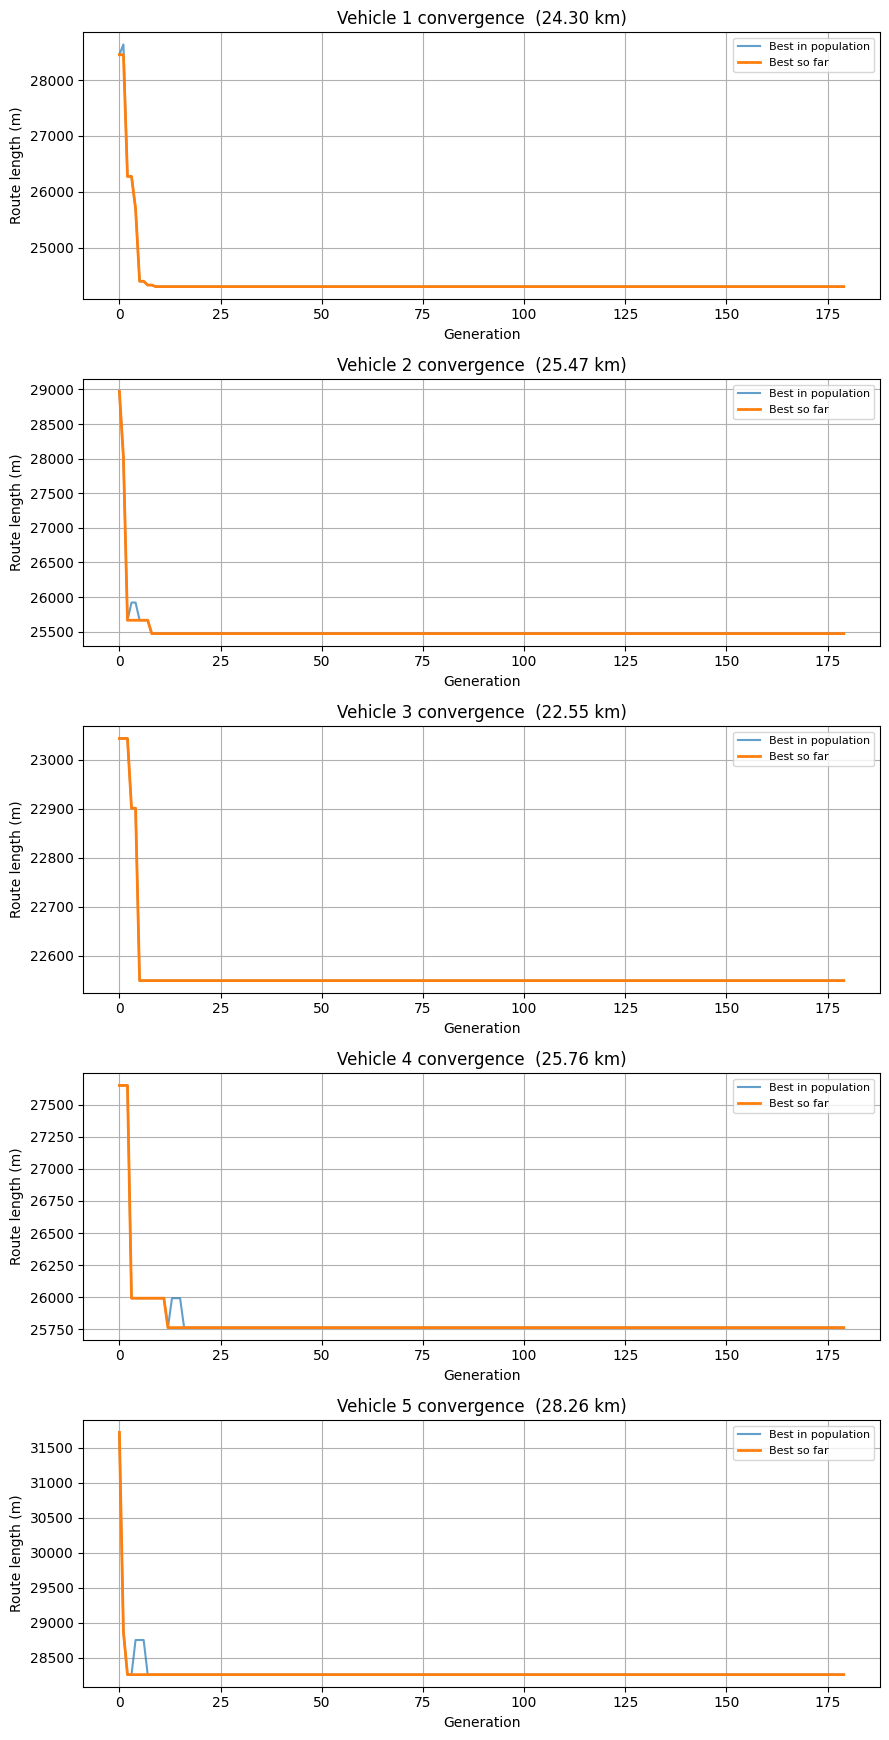

In [11]:
fig, axes = plt.subplots(
    nrows=max(1, len([r for r in vehicle_results if r['history']])),
    ncols=1,
    figsize=(9, 3.5 * max(1, len([r for r in vehicle_results if r['history']]))),
    squeeze=False,
)

plot_idx = 0
for r in vehicle_results:
    if r['history'] is None:
        continue
    ax = axes[plot_idx][0]
    ax.plot(r['history']['best_in_population'], label='Best in population', alpha=0.7)
    ax.plot(r['history']['best_so_far'],        label='Best so far',        linewidth=2)
    ax.set_title(f"Vehicle {r['vehicle_id']} convergence  ({r['total_dist_m']/1000:.2f} km)")
    ax.set_xlabel('Generation')
    ax.set_ylabel('Route length (m)')
    ax.legend(fontsize=8)
    ax.grid(True)
    plot_idx += 1

plt.tight_layout()
plt.show()



## 6. Inspect chosen traversal directions


In [12]:
def segment_orientation_summary(order, orientations, segments):
    rows = []
    for step, (seg_idx, ori) in enumerate(zip(order, orientations), start=1):
        seg = segments[seg_idx]
        direction  = "A -> B" if ori == 0 else "B -> A"
        entry_idx  = seg["a_idx"] if ori == 0 else seg["b_idx"]
        exit_idx   = seg["b_idx"] if ori == 0 else seg["a_idx"]
        rows.append({
            "step":        step,
            "segment_id":  seg_idx,
            "name":        seg["name"],
            "direction":   direction,
            "entry_label": POINT_LABELS[entry_idx],
            "exit_label":  POINT_LABELS[exit_idx],
        })
    return rows


# ── Print orientation summary for every vehicle ───────────────────────────────
for r in vehicle_results:
    if not r['seg_ids']:
        continue
    print(f"\nVehicle {r['vehicle_id']}  ({r['total_dist_m']/1000:.2f} km)")
    print('-' * 50)
    summary = segment_orientation_summary(
        r['best_order'],
        r['orientations'],
        SEGMENTS,          # use the global SEGMENTS list (best_order holds global indices)
    )
    for row in summary:
        print(f"  Step {row['step']:2d}: [{row['direction']}] {row['name']}")



Vehicle 1  (24.30 km)
--------------------------------------------------
  Step  1: [A -> B] Park Jalan Raya Menur
  Step  2: [B -> A] Park Jalan Arief Rahman Hakim
  Step  3: [B -> A] Park Jalan Doktor Insinyur Haji Soekarno
  Step  4: [A -> B] Park Jalan Dharma Husada Indah II
  Step  5: [A -> B] Park Jalan Kenjeran
  Step  6: [B -> A] Park Jalan Semolowaru
  Step  7: [A -> B] Park Jalan Kertajaya

Vehicle 2  (25.47 km)
--------------------------------------------------
  Step  1: [A -> B] Park Jalan Suko Semolo
  Step  2: [B -> A] Park Jalan Arief Rahman Hakim
  Step  3: [B -> A] Park Jalan Dharmahusada Indah III
  Step  4: [B -> A] Park Jalan Dharmahusada Indah III
  Step  5: [B -> A] Park Jalan Doktor Insinyur Haji Soekarno
  Step  6: [A -> B] Park Jalan Raya Mulyosari
  Step  7: [A -> B] Park Jalan Dharmahusada Permai

Vehicle 3  (22.55 km)
--------------------------------------------------
  Step  1: [A -> B] Park Jalan Suko Semolo
  Step  2: [B -> A] Park Jalan Doktor Insinyur


## 7. Reconstruct full route geometry with OSRM `route`

We request the actual route geometry for each leg using the same plain OSRM `/route` call
(no bearing or `continue_straight` constraints) so that the reconstructed route distances
match the `/table`-based distances optimised by the GA.

Legs:

- depot → first segment entry
- inside each segment (entry → exit)
- between consecutive segments
- final segment exit → depot (optional)

The leg breakdown printed at the end shows GA distance vs OSRM route distance so you
can verify they are consistent (small differences < 1–2 % are normal due to OSRM
internal rounding between the table and route endpoints).


In [13]:
route_cache = {}

def route_key(p1, p2):
    return (round(p1[0], 6), round(p1[1], 6), round(p2[0], 6), round(p2[1], 6))

def osrm_route(p1, p2, overview="full", geometries="geojson"):
    """
    Request a road-network route from p1 to p2 using OSRM /route.
    p1 and p2 should already be SNAPPED_POINTS so results are consistent
    with the /table distances used during GA optimisation.
    """
    key = route_key(p1, p2)
    if key in route_cache:
        return route_cache[key]

    coords = f"{p1[1]:.6f},{p1[0]:.6f};{p2[1]:.6f},{p2[0]:.6f}"
    url = (
        f"{OSRM_BASE}/route/v1/{PROFILE}/{coords}"
        f"?overview={overview}&geometries={geometries}&steps=false"
    )

    r = requests.get(url, timeout=120)
    r.raise_for_status()
    data = r.json()
    if data.get("code") != "Ok":
        raise RuntimeError(data)

    route = data["routes"][0]
    geom  = route["geometry"]["coordinates"]
    latlon = [(lat, lon) for lon, lat in geom]

    out = {
        "distance_m":      float(route["distance"]),
        "duration_s":      float(route["duration"]),
        "geometry_latlon": latlon,
        "raw":             data,
    }
    route_cache[key] = out
    return out

print("osrm_route helper ready.")


osrm_route helper ready.


In [14]:
# Build visit plans and reconstruct full route geometry for each vehicle

def build_visit_plan(order, orientations, segments, vehicle_id=None):
    """Build ordered leg list for one vehicle."""
    plan = []
    current_point = SNAPPED_POINTS[DEPOT_IDX]

    for step, (seg_idx, ori) in enumerate(zip(order, orientations), start=1):
        seg       = segments[seg_idx]
        entry_idx = seg["a_idx"] if ori == 0 else seg["b_idx"]
        exit_idx  = seg["b_idx"] if ori == 0 else seg["a_idx"]
        entry_pt  = SNAPPED_POINTS[entry_idx]
        exit_pt   = SNAPPED_POINTS[exit_idx]

        plan.append({
            "kind":       "move_to_segment",
            "vehicle_id": vehicle_id,
            "step":       step,
            "segment_id": seg_idx,
            "name":       seg["name"],
            "from_pt":    current_point,
            "to_pt":      entry_pt,
            "label":      f"Move to {seg['name']} entry",
        })
        plan.append({
            "kind":       "traverse_segment",
            "vehicle_id": vehicle_id,
            "step":       step,
            "segment_id": seg_idx,
            "name":       seg["name"],
            "from_pt":    entry_pt,
            "to_pt":      exit_pt,
            "label":      f"Traverse {seg['name']}",
        })
        current_point = exit_pt

    if RETURN_TO_DEPOT:
        plan.append({
            "kind":       "return_to_depot",
            "vehicle_id": vehicle_id,
            "step":       len(order) + 1,
            "segment_id": None,
            "name":       "Depot",
            "from_pt":    current_point,
            "to_pt":      SNAPPED_POINTS[DEPOT_IDX],
            "label":      "Return to depot",
        })
    return plan


# ── Reconstruct geometry for all vehicles ────────────────────────────────────
for r in vehicle_results:
    if not r['seg_ids']:
        r['visit_plan']        = []
        r['full_route_coords'] = []
        r['leg_summaries']     = []
        continue

    visit_plan = build_visit_plan(
        r['best_order'],
        r['orientations'],
        SEGMENTS,
        vehicle_id=r['vehicle_id'],
    )

    full_route_coords = []
    leg_summaries     = []

    for i, leg in enumerate(visit_plan, start=1):
        result = osrm_route(leg["from_pt"], leg["to_pt"])
        geom   = result["geometry_latlon"]
        if full_route_coords and geom:
            geom = geom[1:]
        full_route_coords.extend(geom)
        leg_summaries.append({
            "leg_no":      i,
            "kind":        leg["kind"],
            "label":       leg["label"],
            "distance_m":  result["distance_m"],
            "duration_min": result["duration_s"] / 60.0,
        })

    r['visit_plan']        = visit_plan
    r['full_route_coords'] = full_route_coords
    r['leg_summaries']     = leg_summaries

    route_total_m = sum(x["distance_m"] for x in leg_summaries)
    print(f"Vehicle {r['vehicle_id']:2d}: "
          f"GA={r['total_dist_m']:,.0f} m  "
          f"OSRM={route_total_m:,.0f} m  "
          f"diff={abs(route_total_m - r['total_dist_m']):,.0f} m")


Vehicle  1: GA=24,300 m  OSRM=24,300 m  diff=0 m
Vehicle  2: GA=25,472 m  OSRM=25,472 m  diff=0 m
Vehicle  3: GA=22,549 m  OSRM=22,549 m  diff=0 m
Vehicle  4: GA=25,764 m  OSRM=25,764 m  diff=0 m
Vehicle  5: GA=28,263 m  OSRM=28,263 m  diff=0 m



## 8. Visualize on interactive OSM map


In [15]:
# ── Colour palette for vehicles (auto-cycles if NUM_VEHICLES > len palette) ──
VEHICLE_COLORS = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
]

center = DEPOT
m = folium.Map(
    location=center,
    zoom_start=13,
    tiles='https://tile.openstreetmap.de/{z}/{x}/{y}.png',
    attr='© OpenStreetMap contributors',
)

# Depot marker
folium.Marker(
    DEPOT,
    tooltip='Depot / Start',
    icon=folium.Icon(color='red', icon='home', prefix='fa'),
).add_to(m)

if RETURN_TO_DEPOT:
    folium.Marker(
        DEPOT,
        tooltip='Depot / End',
        icon=folium.DivIcon(html='''
            <div style="font-size:9pt;font-weight:bold;color:white;
                        background:#d62728;border:2px solid white;
                        border-radius:10px;padding:2px 6px;
                        transform:translate(14px,-18px);">END</div>
        ''')
    ).add_to(m)

# Draw each vehicle's route and segment markers
for r in vehicle_results:
    if not r['seg_ids']:
        continue

    v_color = VEHICLE_COLORS[(r['vehicle_id'] - 1) % len(VEHICLE_COLORS)]
    v_label = f"Vehicle {r['vehicle_id']}"

    # Route polyline
    if r['full_route_coords']:
        folium.PolyLine(
            r['full_route_coords'],
            color=v_color,
            weight=4,
            opacity=0.8,
            tooltip=f"{v_label}: {r['total_dist_m']/1000:.2f} km",
        ).add_to(m)

    # Segment endpoint markers
    for seg_idx in r['seg_ids']:
        seg = SEGMENTS[seg_idx]
        a   = SNAPPED_POINTS[seg['a_idx']]
        b   = SNAPPED_POINTS[seg['b_idx']]

        for pt, lbl in [(a, 'A'), (b, 'B')]:
            folium.CircleMarker(
                pt, radius=5, color=v_color, weight=2,
                fill=True, fill_color=v_color, fill_opacity=0.9,
                tooltip=f"{v_label} | {seg['name']} {lbl}",
            ).add_to(m)
            folium.Marker(
                pt,
                icon=folium.DivIcon(html=f'''
                    <div style="font-size:7pt;font-weight:bold;
                                color:{v_color};
                                background:rgba(255,255,255,0.85);
                                border:1px solid {v_color};
                                border-radius:6px;padding:1px 3px;
                                transform:translate(7px,-12px);
                                white-space:nowrap;">{lbl}</div>
                '''),
            ).add_to(m)

    # Step number labels at each segment entry point
    for step, (seg_idx, ori) in enumerate(zip(r['best_order'], r['orientations']), start=1):
        seg       = SEGMENTS[seg_idx]
        entry_idx = seg['a_idx'] if ori == 0 else seg['b_idx']
        entry_pt  = SNAPPED_POINTS[entry_idx]
        offset_x  = 18 + (step % 3) * 6
        offset_y  = -28 - (step % 2) * 6

        folium.Marker(
            entry_pt,
            tooltip=f"{v_label} Step {step}: {seg['name']} ({'A->B' if ori == 0 else 'B->A'})",
            icon=folium.DivIcon(html=f'''
                <div style="font-size:9pt;font-weight:bold;color:white;
                            background:{v_color};border:2px solid white;
                            border-radius:12px;padding:2px 5px;
                            min-width:20px;text-align:center;
                            transform:translate({offset_x}px,{offset_y}px);
                            box-shadow:0 0 4px rgba(0,0,0,0.5);"
                >{step}</div>
            '''),
        ).add_to(m)

m


## Notes

- **Multi-vehicle extension**: `NUM_VEHICLES` controls the fleet size. Segments are
  distributed using `ASSIGNMENT_STRATEGY` (`'round_robin'` or `'block'`). Each vehicle
  runs its own GA on its assigned segments; the global OSRM distance matrix is shared.
- If `NUM_VEHICLES` exceeds the number of segments, the effective number of active
  vehicles is capped at `len(SEGMENTS)`.
- Each vehicle starts and ends at the same `DEPOT` (when `RETURN_TO_DEPOT = True`).
- Routes are colour-coded on the map; hovering a polyline shows the vehicle ID and
  its total distance.
- OSRM `/table` builds the shared pairwise road-distance matrix; OSRM `/route`
  reconstructs the real driving geometry per leg.
- Small discrepancies (<2%) between GA-optimised and OSRM `/route` distances are
  normal due to internal rounding between OSRM table and route endpoints.
- To optimise **travel time** instead of distance, switch to OSRM duration values
  in the table and route responses.
